In [1]:
# =============================================================================
# ARIMAX & SARIMAX — Adding Exogenous Variables to Time Series Models
# =============================================================================
# Dataset  : AirPassengers (1949-1960) + Synthetic Exogenous Variables
# Models   : ARIMA → ARIMAX → SARIMA → SARIMAX → Auto SARIMAX
#
# Exogenous variables (synthetic, designed for teaching):
#   X1 : oil_index    — gradual rise + noise  (simulates fuel cost pressure)
#   X2 : recession    — binary dummy          (1953, 1957-58 US recessions)
#   X3 : marketing    — pulse campaign dummy  (every summer, 1954+)
#
# Learning Flow:
#   SECTION 0 : Data & Exogenous Variable Construction
#   SECTION 1 : Why Add Exogenous Variables? (Residual Analysis)
#   SECTION 2 : ARIMAX — ARIMA + Exogenous
#   SECTION 3 : SARIMAX — SARIMA + Exogenous
#   SECTION 4 : Exogenous Variable Importance
#   SECTION 5 : Auto SARIMAX (pmdarima)
#   SECTION 6 : Model Comparison — ARIMA / ARIMAX / SARIMA / SARIMAX
#   SECTION 7 : Future Forecast with Exogenous (1961)
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

# ─────────────────────────────────────────────────────────────────────────────
# AirPassengers inline data
# Replace with: from statsmodels.datasets import get_rdataset
#               raw = get_rdataset("AirPassengers","datasets").data
# ─────────────────────────────────────────────────────────────────────────────
_AP = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
]



In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Utilities
# ─────────────────────────────────────────────────────────────────────────────

def compute_metrics(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, mape

def print_metrics(label, mae, rmse, mape):
    grade = "Excellent" if mape < 10 else "Good" if mape < 20 else "Acceptable"
    print(f"  {label:<35}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  MAPE={mape:5.2f}%  [{grade}]")

def plot_forecast(ax, train, test, fc_vals,
                  ci_lo=None, ci_hi=None,
                  title="", fc_color="#F96167"):
    ax.plot(train.index, train.values,
            color="#1C7293", lw=1.8, label="Train")
    ax.plot(test.index, test.values,
            color="#028090", lw=1.8, ls="--", label="Actual (Test)")
    ax.plot(test.index, fc_vals,
            color=fc_color, lw=2.2, label="Forecast")
    if ci_lo is not None:
        ax.fill_between(test.index, ci_lo, ci_hi,
                        color=fc_color, alpha=0.18, label="95% CI")
    ax.axvline(test.index[0], color="gray", ls=":", lw=1.0)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Passengers (thousands)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)



In [3]:
# =============================================================================
# SECTION 0 : Data & Exogenous Variable Construction
# =============================================================================
print("=" * 65)
print("  SECTION 0 : Data & Exogenous Variable Construction")
print("=" * 65)

idx = pd.date_range(start="1949-01", periods=144, freq="MS")
data = pd.Series(_AP, index=idx, name="passengers")
log_data = np.log(data)

np.random.seed(42)
n = 144

# ── X1 : Oil Price Index ──────────────────────────────────────────────────────
# Gradual upward trend (20→30) + random noise
# Rationale: higher fuel cost → airline ticket prices rise → demand falls
oil_index = 20 + np.linspace(0, 10, n) + np.random.normal(0, 1.2, n)

# ── X2 : Recession Dummy ──────────────────────────────────────────────────────
# Based on actual US recessions:
#   1953-07 ~ 1954-05  (Korean War aftermath)
#   1957-08 ~ 1958-04  (Eisenhower recession)
recession = np.zeros(n)
recession[54:65]  = 1   # 1953-07 ~ 1954-05
recession[103:112] = 1  # 1957-08 ~ 1958-04

# ── X3 : Summer Marketing Campaign Dummy ────────────────────────────────────
# Airline ran summer promotions starting 1954 (month 60 onward)
# Active every Jun-Aug from 1954
marketing = np.zeros(n)
for yr in range(1954, 1961):
    start = (yr - 1949) * 12
    for m in [5, 6, 7]:   # Jun=5, Jul=6, Aug=7 (0-indexed)
        if start + m < n:
            marketing[start + m] = 1

# Combine into DataFrame
exog = pd.DataFrame({
    "oil_index":  oil_index,
    "recession":  recession,
    "marketing":  marketing,
}, index=idx)

print(f"\n  Target Y  : passengers (1949-01 ~ 1960-12, n={n})")
print(f"  Exog vars : {list(exog.columns)}")
print(f"\n  oil_index : gradual rise 20→30 + noise (simulates fuel cost)")
print(f"  recession : binary dummy  (1=recession period)")
print(f"              1953-07~1954-05, 1957-08~1958-04")
print(f"  marketing : binary dummy  (1=summer campaign active)")
print(f"              Jun/Jul/Aug from 1954 onward")
print(f"\n  Exog preview:")
print(exog[exog["recession"] == 1].head(6).to_string())



  SECTION 0 : Data & Exogenous Variable Construction

  Target Y  : passengers (1949-01 ~ 1960-12, n=144)
  Exog vars : ['oil_index', 'recession', 'marketing']

  oil_index : gradual rise 20→30 + noise (simulates fuel cost)
  recession : binary dummy  (1=recession period)
              1953-07~1954-05, 1957-08~1958-04
  marketing : binary dummy  (1=summer campaign active)
              Jun/Jul/Aug from 1954 onward

  Exog preview:
            oil_index  recession  marketing
1953-07-01  25.013423        1.0        0.0
1953-08-01  24.963690        1.0        0.0
1953-09-01  22.909023        1.0        0.0
1953-10-01  23.614959        1.0        0.0
1953-11-01  24.453460        1.0        0.0
1953-12-01  25.296528        1.0        0.0


In [4]:
# ── Train / Test split ───────────────────────────────────────────────────────
train_raw  = data[:"1957-12"];      test_raw  = data["1958-01":]
train_log  = log_data[:"1957-12"];  test_log  = log_data["1958-01":]
exog_train = exog[:"1957-12"];      exog_test = exog["1958-01":]

print(f"\n  Train: 1949-01 ~ 1957-12  ({len(train_raw)} obs)")
print(f"  Test : 1958-01 ~ 1960-12  ({len(test_raw)} obs)")




  Train: 1949-01 ~ 1957-12  (108 obs)
  Test : 1958-01 ~ 1960-12  (36 obs)


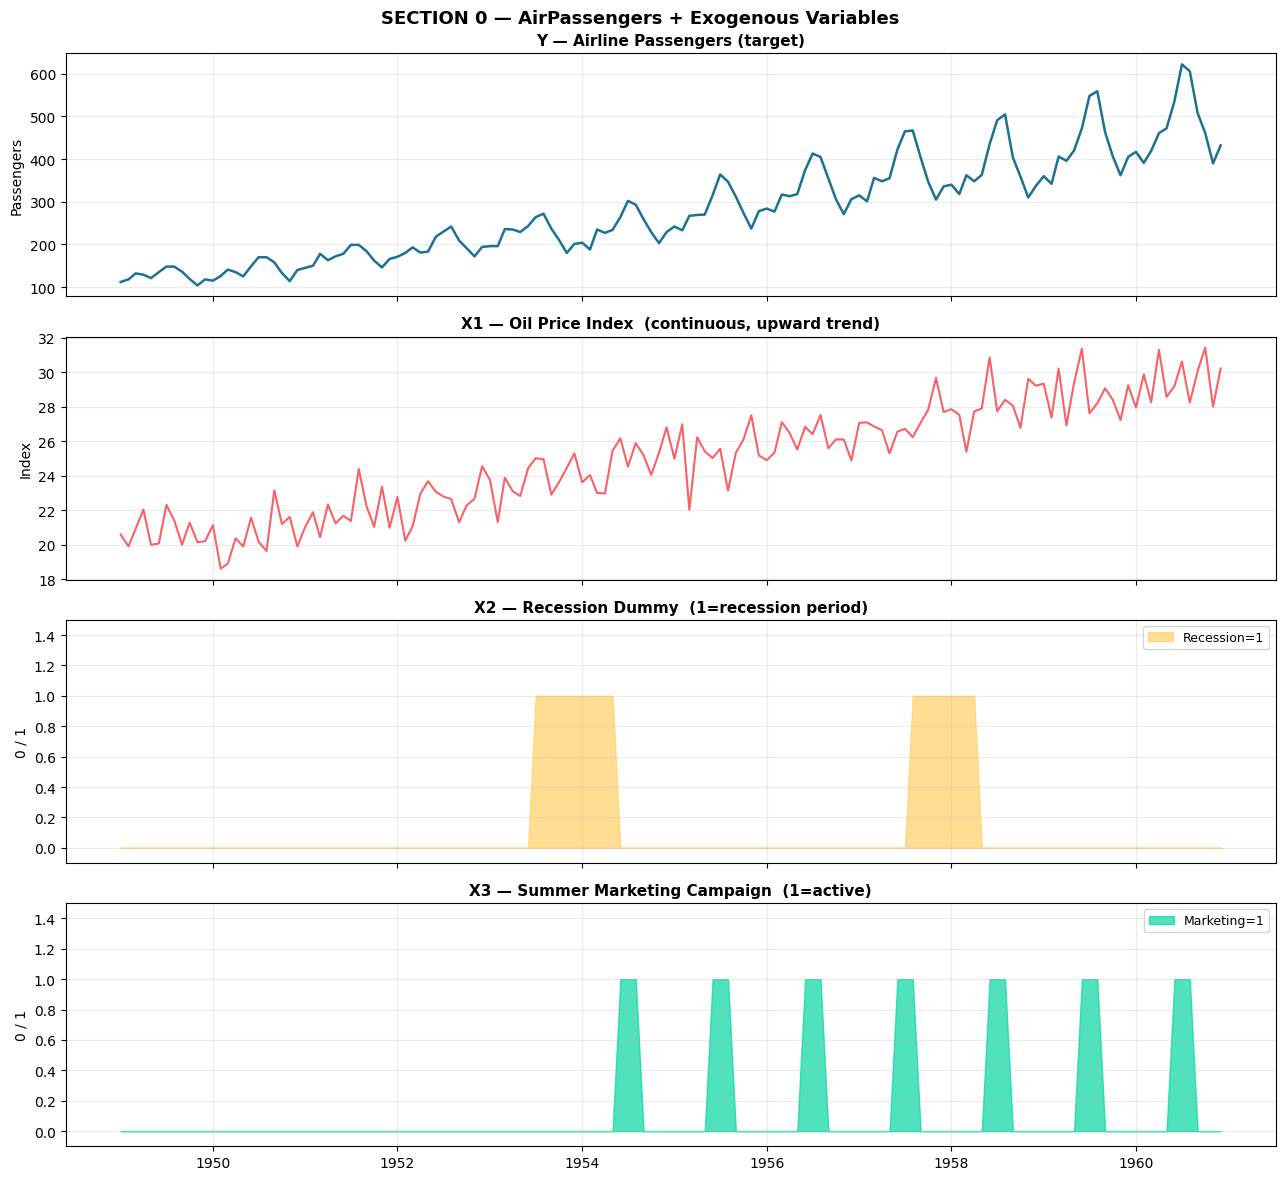

In [5]:
# ── Overview plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(data.index, data.values, color="#1C7293", lw=1.8)
axes[0].set_title("Y — Airline Passengers (target)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Passengers"); axes[0].grid(True, alpha=0.25)

axes[1].plot(exog.index, exog["oil_index"], color="#F96167", lw=1.5)
axes[1].set_title("X1 — Oil Price Index  (continuous, upward trend)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Index"); axes[1].grid(True, alpha=0.25)

axes[2].fill_between(exog.index, exog["recession"],
                     color="#FFD166", alpha=0.7, label="Recession=1")
axes[2].set_title("X2 — Recession Dummy  (1=recession period)",
                  fontsize=11, fontweight="bold")
axes[2].set_ylabel("0 / 1"); axes[2].set_ylim(-0.1, 1.5)
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.25)

axes[3].fill_between(exog.index, exog["marketing"],
                     color="#06D6A0", alpha=0.7, label="Marketing=1")
axes[3].set_title("X3 — Summer Marketing Campaign  (1=active)",
                  fontsize=11, fontweight="bold")
axes[3].set_ylabel("0 / 1"); axes[3].set_ylim(-0.1, 1.5)
axes[3].legend(fontsize=9); axes[3].grid(True, alpha=0.25)

plt.suptitle("SECTION 0 — AirPassengers + Exogenous Variables",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 1 : Why Add Exogenous Variables?

  Motivation:
    Pure SARIMA assumes all information is in the series itself.
    But real-world series are driven by EXTERNAL factors:
      - Economic shocks (recession)
      - Cost changes (oil price)
      - Interventions (marketing campaigns)

    If these effects are NOT modeled:
      → They end up in the RESIDUALS
      → Residuals show patterns (autocorrelation remains)
      → Model is mis-specified → forecast degrades

  ARIMAX / SARIMAX explicitly include X variables:
      Y_t = ARIMA(p,d,q) + β₁X₁_t + β₂X₂_t + ... + βₖXₖ_t



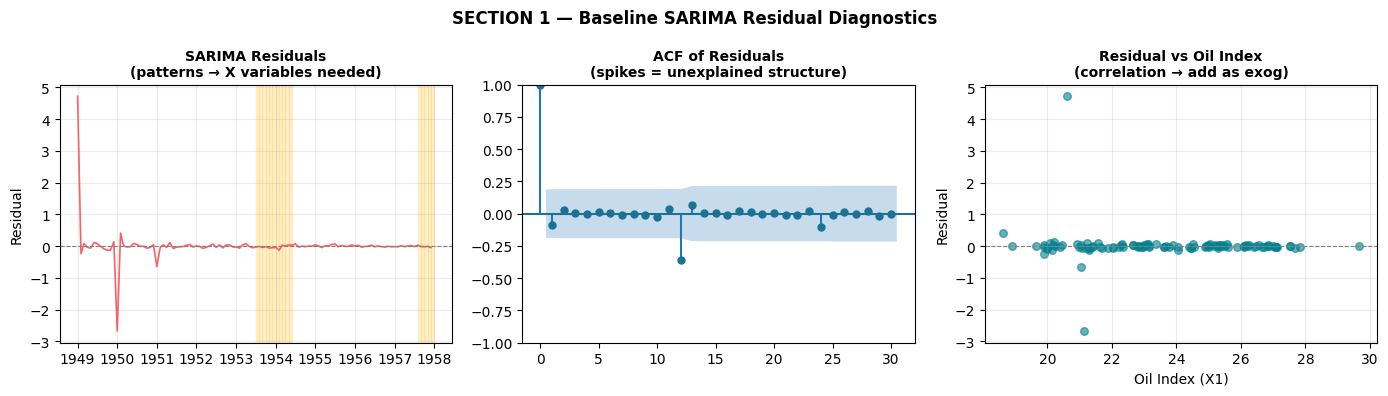

In [6]:
# =============================================================================
# SECTION 1 : Why Add Exogenous Variables? (Residual Analysis)
# =============================================================================
print("\n" + "=" * 65)
print("  SECTION 1 : Why Add Exogenous Variables?")
print("=" * 65)
print("""
  Motivation:
    Pure SARIMA assumes all information is in the series itself.
    But real-world series are driven by EXTERNAL factors:
      - Economic shocks (recession)
      - Cost changes (oil price)
      - Interventions (marketing campaigns)

    If these effects are NOT modeled:
      → They end up in the RESIDUALS
      → Residuals show patterns (autocorrelation remains)
      → Model is mis-specified → forecast degrades

  ARIMAX / SARIMAX explicitly include X variables:
      Y_t = ARIMA(p,d,q) + β₁X₁_t + β₂X₂_t + ... + βₖXₖ_t
""")

# Fit baseline SARIMA (no exog) to inspect residuals
baseline = SARIMAX(train_log,
                   order=(1,1,1),
                   seasonal_order=(1,1,1,12),
                   enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False)

residuals = baseline.resid

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(residuals.index, residuals.values, color="#F96167", lw=1.2)
axes[0].axhline(0, color="gray", ls="--", lw=0.8)
axes[0].set_title("SARIMA Residuals\n(patterns → X variables needed)",
                  fontsize=10, fontweight="bold")
axes[0].grid(True, alpha=0.25)

# Shade recession periods in residual plot
for i in range(n):
    if recession[i] == 1 and i < len(train_raw):
        axes[0].axvspan(idx[i], idx[min(i+1, n-1)],
                        color="#FFD166", alpha=0.3)
axes[0].set_ylabel("Residual")

plot_acf(residuals.dropna(), lags=30, ax=axes[1], color="#1C7293")
axes[1].set_title("ACF of Residuals\n(spikes = unexplained structure)",
                  fontsize=10, fontweight="bold")

axes[2].scatter(exog_train["oil_index"], residuals.dropna(),
                color="#028090", alpha=0.6, s=30)
axes[2].axhline(0, color="gray", ls="--", lw=0.8)
axes[2].set_xlabel("Oil Index (X1)"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residual vs Oil Index\n(correlation → add as exog)",
                  fontsize=10, fontweight="bold")
axes[2].grid(True, alpha=0.25)

plt.suptitle("SECTION 1 — Baseline SARIMA Residual Diagnostics",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 2 : ARIMAX — ARIMA + Exogenous Variables

  Formula:
    ARIMAX(p, d, q)  with exogenous matrix X
    Y_t = c + AR(p) + MA(q) + β₁X₁_t + β₂X₂_t + β₃X₃_t + ε_t
          └── ARIMA part ───┘ └────── exogenous part ──────┘

  Key points:
    - ARIMA handles: autocorrelation + trend (differencing d)
    - X variables handle: external shocks and interventions
    - Coefficients β are estimated jointly with AR/MA params
    - β interpretation: 1-unit increase in X → β change in Y (log scale)

  Applied here:
    ARIMAX(2, 1, 2) + [oil_index, recession, marketing]
    No seasonal component → compare to SARIMAX later

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  108
Model:               SARIMAX(2, 1, 2)   Log Likelihood                  99.596
Date:                Fri, 17 Apr 2026   AIC                           -183.192
Time:                        20:46:27   BIC            

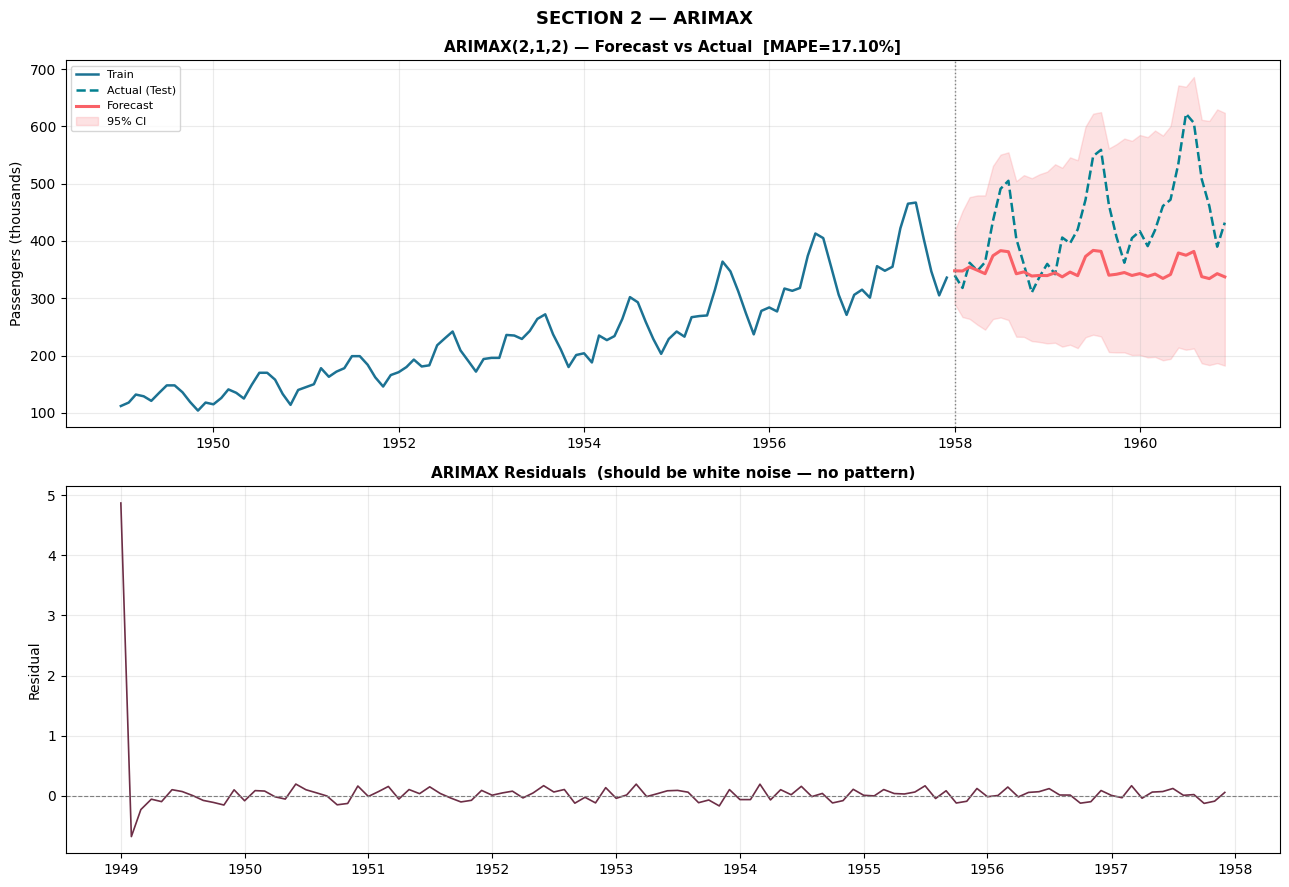

In [7]:
# =============================================================================
# SECTION 2 : ARIMAX — ARIMA + Exogenous Variables
# =============================================================================
print("\n" + "=" * 65)
print("  SECTION 2 : ARIMAX — ARIMA + Exogenous Variables")
print("=" * 65)
print("""
  Formula:
    ARIMAX(p, d, q)  with exogenous matrix X
    Y_t = c + AR(p) + MA(q) + β₁X₁_t + β₂X₂_t + β₃X₃_t + ε_t
          └── ARIMA part ───┘ └────── exogenous part ──────┘

  Key points:
    - ARIMA handles: autocorrelation + trend (differencing d)
    - X variables handle: external shocks and interventions
    - Coefficients β are estimated jointly with AR/MA params
    - β interpretation: 1-unit increase in X → β change in Y (log scale)

  Applied here:
    ARIMAX(2, 1, 2) + [oil_index, recession, marketing]
    No seasonal component → compare to SARIMAX later
""")

# ── Fit ARIMAX ────────────────────────────────────────────────────────────────
arimax_model = SARIMAX(
    train_log,
    exog  = exog_train,
    order = (2, 1, 2),
    enforce_stationarity = False,
    enforce_invertibility= False
).fit(disp=False)

print(arimax_model.summary())

# ── Coefficient interpretation ────────────────────────────────────────────────
print("\n  Exogenous Coefficient Interpretation (log scale):")
params = arimax_model.params
for xname in exog.columns:
    if xname in params.index:
        b = params[xname]
        pv = arimax_model.pvalues[xname]
        sig = "***" if pv < 0.01 else "**" if pv < 0.05 else "*" if pv < 0.1 else "(n.s.)"
        print(f"  β_{xname:<12} = {b:+.4f}  (p={pv:.4f}) {sig}")
        if xname == "oil_index":
            print(f"    → 1-unit rise in oil index changes log(passengers) by {b:+.4f}")
        elif xname == "recession":
            print(f"    → Recession period changes log(passengers) by {b:+.4f}  "
                  f"≈ {(np.exp(b)-1)*100:+.1f}% change in passengers")
        elif xname == "marketing":
            print(f"    → Marketing campaign changes log(passengers) by {b:+.4f}  "
                  f"≈ {(np.exp(b)-1)*100:+.1f}% change in passengers")

# ── Forecast ──────────────────────────────────────────────────────────────────
arimax_fc_obj = arimax_model.get_forecast(steps=len(test_log), exog=exog_test)
arimax_fc     = np.exp(arimax_fc_obj.predicted_mean)
arimax_ci     = np.exp(arimax_fc_obj.conf_int())
arimax_ci_lo  = arimax_ci.iloc[:,0]
arimax_ci_hi  = arimax_ci.iloc[:,1]

mae_arimax, rmse_arimax, mape_arimax = compute_metrics(test_raw, arimax_fc)
print_metrics("ARIMAX(2,1,2)+exog", mae_arimax, rmse_arimax, mape_arimax)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Top: forecast vs actual
plot_forecast(axes[0], train_raw, test_raw, arimax_fc.values,
              ci_lo=arimax_ci_lo.values, ci_hi=arimax_ci_hi.values,
              title=f"ARIMAX(2,1,2) — Forecast vs Actual  [MAPE={mape_arimax:.2f}%]",
              fc_color="#F96167")

# Bottom: residual diagnostics
resid_arimax = arimax_model.resid
axes[1].plot(resid_arimax.index, resid_arimax.values,
             color="#6D2E46", lw=1.2)
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_title("ARIMAX Residuals  (should be white noise — no pattern)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Residual"); axes[1].grid(True, alpha=0.25)

plt.suptitle("SECTION 2 — ARIMAX", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 3 : SARIMAX — SARIMA + Exogenous Variables

  Formula:
    SARIMAX(p,d,q)(P,D,Q,s)  with exogenous matrix X
    Y_t = SARIMA(p,d,q)(P,D,Q,s) + β₁X₁_t + β₂X₂_t + β₃X₃_t + ε_t
          └──── seasonal ARIMA ────┘ └────── exogenous ──────────┘

  vs ARIMAX:
    ARIMAX  : handles trend only  (no seasonal component)
    SARIMAX : handles trend + seasonality + external variables
              → most complete model

  Applied here:
    SARIMAX(1,1,1)(1,1,1,12) + [oil_index, recession, marketing]
    → best of all worlds



/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 150.888
Date:                            Fri, 17 Apr 2026   AIC                           -285.777
Time:                                    20:47:30   BIC                           -266.621
Sample:                                01-01-1949   HQIC                          -278.091
                                     - 12-01-1957                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
oil_index     -0.0012      0.003     -0.363      0.716      -0.008       0.005
recession     -0.0152      0.020   

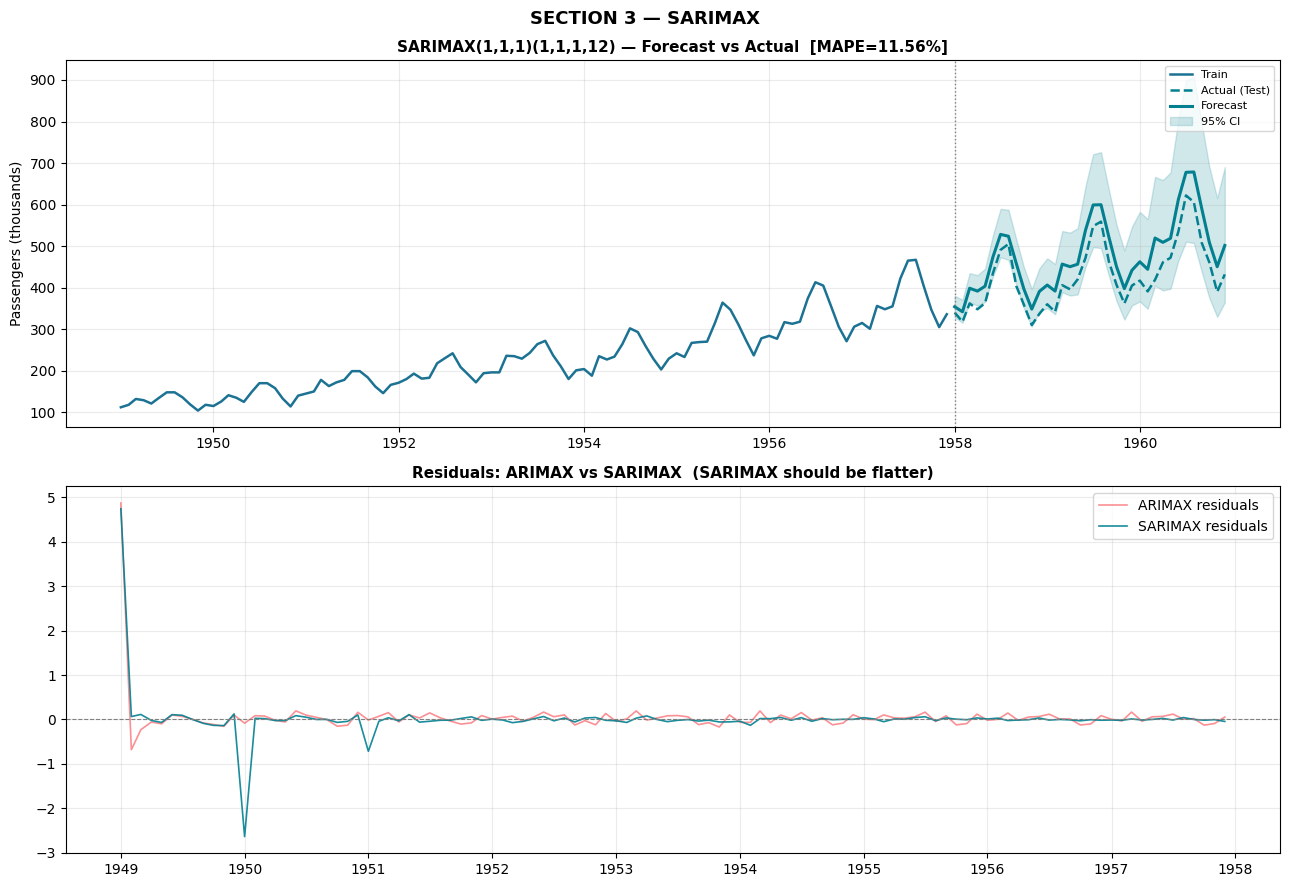

In [8]:
# =============================================================================
# SECTION 3 : SARIMAX — SARIMA + Exogenous Variables
# =============================================================================
print("\n" + "=" * 65)
print("  SECTION 3 : SARIMAX — SARIMA + Exogenous Variables")
print("=" * 65)
print("""
  Formula:
    SARIMAX(p,d,q)(P,D,Q,s)  with exogenous matrix X
    Y_t = SARIMA(p,d,q)(P,D,Q,s) + β₁X₁_t + β₂X₂_t + β₃X₃_t + ε_t
          └──── seasonal ARIMA ────┘ └────── exogenous ──────────┘

  vs ARIMAX:
    ARIMAX  : handles trend only  (no seasonal component)
    SARIMAX : handles trend + seasonality + external variables
              → most complete model

  Applied here:
    SARIMAX(1,1,1)(1,1,1,12) + [oil_index, recession, marketing]
    → best of all worlds
""")

# ── Fit SARIMAX ───────────────────────────────────────────────────────────────
sarimax_model = SARIMAX(
    train_log,
    exog           = exog_train,
    order          = (1, 1, 1),
    seasonal_order = (1, 1, 1, 12),
    enforce_stationarity = False,
    enforce_invertibility= False
).fit(disp=False)

print(sarimax_model.summary())

# ── Coefficient interpretation ────────────────────────────────────────────────
print("\n  Exogenous Coefficient Interpretation (log scale):")
params_s = sarimax_model.params
for xname in exog.columns:
    if xname in params_s.index:
        b  = params_s[xname]
        pv = sarimax_model.pvalues[xname]
        sig = "***" if pv < 0.01 else "**" if pv < 0.05 else "*" if pv < 0.1 else "(n.s.)"
        effect_pct = (np.exp(b) - 1) * 100
        print(f"  β_{xname:<12} = {b:+.4f}  (p={pv:.4f}) {sig}  "
              f"→ {effect_pct:+.1f}% passengers")

# ── Forecast ──────────────────────────────────────────────────────────────────
sarimax_fc_obj = sarimax_model.get_forecast(steps=len(test_log), exog=exog_test)
sarimax_fc     = np.exp(sarimax_fc_obj.predicted_mean)
sarimax_ci     = np.exp(sarimax_fc_obj.conf_int())
sarimax_ci_lo  = sarimax_ci.iloc[:,0]
sarimax_ci_hi  = sarimax_ci.iloc[:,1]

mae_sarimax, rmse_sarimax, mape_sarimax = compute_metrics(test_raw, sarimax_fc)
print_metrics("SARIMAX(1,1,1)(1,1,1,12)+exog", mae_sarimax, rmse_sarimax, mape_sarimax)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

plot_forecast(axes[0], train_raw, test_raw, sarimax_fc.values,
              ci_lo=sarimax_ci_lo.values, ci_hi=sarimax_ci_hi.values,
              title=f"SARIMAX(1,1,1)(1,1,1,12) — Forecast vs Actual  [MAPE={mape_sarimax:.2f}%]",
              fc_color="#028090")

# Residuals vs ARIMAX residuals
axes[1].plot(resid_arimax.index, resid_arimax.values,
             color="#F96167", lw=1.2, alpha=0.7, label="ARIMAX residuals")
axes[1].plot(sarimax_model.resid.index, sarimax_model.resid.values,
             color="#028090", lw=1.2, alpha=0.9, label="SARIMAX residuals")
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_title("Residuals: ARIMAX vs SARIMAX  (SARIMAX should be flatter)",
                  fontsize=11, fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.suptitle("SECTION 3 — SARIMAX", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 4 : Exogenous Variable Importance

  Strategy: Ablation study
    Train SARIMAX variants by removing one X at a time.
    Compare MAPE → variables that hurt most when removed = most important.



/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX + all X                      MAE= 49.17  RMSE= 52.01  MAPE=11.56%  [Good]


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX − oil_index                  MAE= 49.56  RMSE= 52.45  MAPE=11.65%  [Good]


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX − recession                  MAE= 36.19  RMSE= 38.68  MAPE= 8.64%  [Excellent]


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX − marketing                  MAE= 54.41  RMSE= 57.61  MAPE=12.73%  [Good]
  SARIMAX (no exog)                    MAE= 37.77  RMSE= 40.28  MAPE= 8.99%  [Excellent]


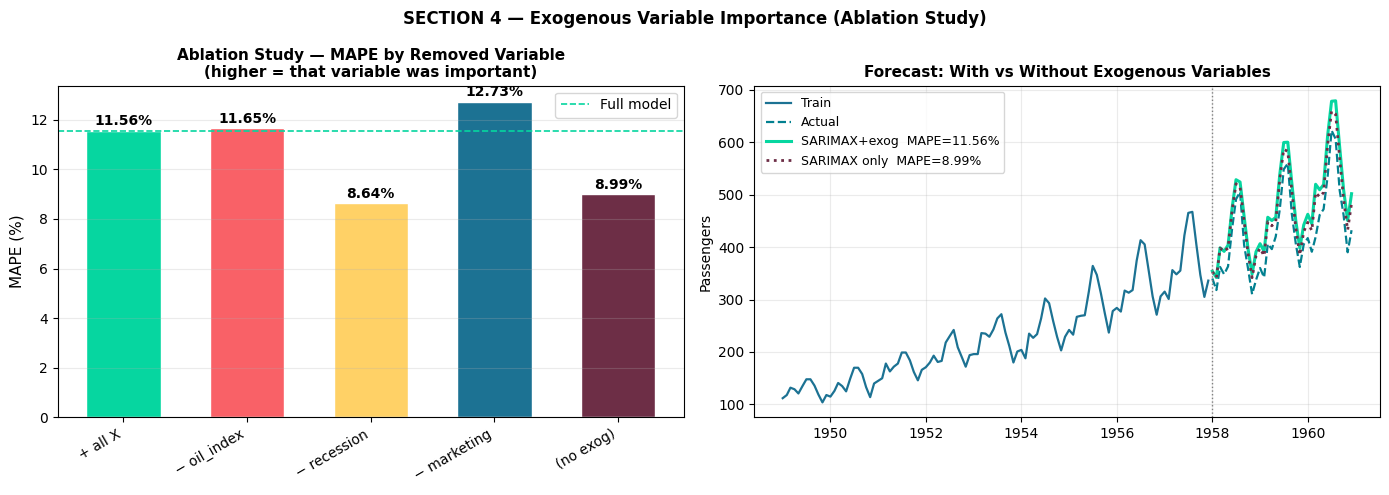

In [9]:
# =============================================================================
# SECTION 4 : Exogenous Variable Importance
# =============================================================================
print("\n" + "=" * 65)
print("  SECTION 4 : Exogenous Variable Importance")
print("=" * 65)
print("""
  Strategy: Ablation study
    Train SARIMAX variants by removing one X at a time.
    Compare MAPE → variables that hurt most when removed = most important.
""")

# Full model already fitted above
variants = {
    "SARIMAX + all X":          exog_train,
    "SARIMAX − oil_index":      exog_train[["recession","marketing"]],
    "SARIMAX − recession":      exog_train[["oil_index","marketing"]],
    "SARIMAX − marketing":      exog_train[["oil_index","recession"]],
    "SARIMAX (no exog)":        None,
}
variants_test = {
    "SARIMAX + all X":          exog_test,
    "SARIMAX − oil_index":      exog_test[["recession","marketing"]],
    "SARIMAX − recession":      exog_test[["oil_index","marketing"]],
    "SARIMAX − marketing":      exog_test[["oil_index","recession"]],
    "SARIMAX (no exog)":        None,
}

ablation_results = {}
for name, exog_tr in variants.items():
    exog_te = variants_test[name]
    m = SARIMAX(train_log, exog=exog_tr,
                order=(1,1,1), seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False).fit(disp=False)
    fc = np.exp(m.get_forecast(steps=len(test_log),
                               exog=exog_te).predicted_mean)
    mae, rmse, mape = compute_metrics(test_raw, fc)
    ablation_results[name] = {"mae":mae, "rmse":rmse, "mape":mape, "fc":fc}
    print_metrics(name, mae, rmse, mape)

# ── Ablation bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(ablation_results.keys())
mapes  = [ablation_results[n]["mape"] for n in names]
colors_bar = ["#06D6A0","#F96167","#FFD166","#1C7293","#6D2E46"]

bars = axes[0].bar(range(len(names)), mapes, color=colors_bar, edgecolor="white", width=0.6)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels([n.replace("SARIMAX","") for n in names],
                         rotation=30, ha="right", fontsize=10)
axes[0].set_ylabel("MAPE (%)", fontsize=11)
axes[0].set_title("Ablation Study — MAPE by Removed Variable\n(higher = that variable was important)",
                  fontsize=11, fontweight="bold")
axes[0].axhline(mapes[0], color="#06D6A0", ls="--", lw=1.2, label="Full model")
axes[0].legend(); axes[0].grid(True, alpha=0.25, axis="y")
for bar, val in zip(bars, mapes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Forecast comparison (full vs no-exog)
axes[1].plot(train_raw.index, train_raw.values,
             color="#1C7293", lw=1.6, label="Train")
axes[1].plot(test_raw.index, test_raw.values,
             color="#028090", lw=1.6, ls="--", label="Actual")
axes[1].plot(test_raw.index, ablation_results["SARIMAX + all X"]["fc"].values,
             color="#06D6A0", lw=2.2, label=f'SARIMAX+exog  MAPE={mapes[0]:.2f}%')
axes[1].plot(test_raw.index, ablation_results["SARIMAX (no exog)"]["fc"].values,
             color="#6D2E46", lw=2.0, ls=":", label=f'SARIMAX only  MAPE={mapes[-1]:.2f}%')
axes[1].axvline(test_raw.index[0], color="gray", ls=":", lw=1.0)
axes[1].set_title("Forecast: With vs Without Exogenous Variables",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Passengers"); axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.25)

plt.suptitle("SECTION 4 — Exogenous Variable Importance (Ablation Study)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 5 : Auto SARIMAX (pmdarima)

  auto_arima() accepts exogenous variables directly via X parameter.
  It auto-selects (p,d,q)(P,D,Q) while holding X fixed.

  Key:
    - Pass exog=X_train during fitting
    - Pass X=X_test during predict (mandatory)
    - Order selection is still AIC-based; X is always included

  Running auto_arima with exog ...

  Auto SARIMAX selected order: (0, 1, 1)  seasonal: (1, 0, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  108
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 188.224
Date:                            Fri, 17 Apr 2026   AIC                           -362.449
Time:                                    20:48:47   BIC                           -343.739
Sample:                                01-01-1949   HQIC                          -354.864
                             

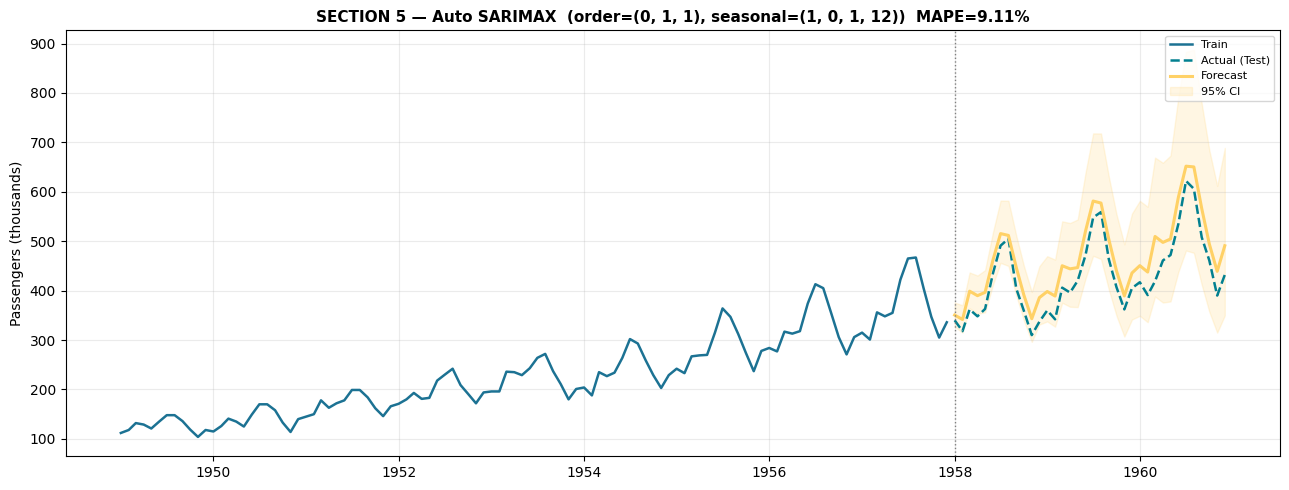

In [10]:
# =============================================================================
# SECTION 5 : Auto SARIMAX (pmdarima)
# =============================================================================
print("\n" + "=" * 65)
print("  SECTION 5 : Auto SARIMAX (pmdarima)")
print("=" * 65)
print("""
  auto_arima() accepts exogenous variables directly via X parameter.
  It auto-selects (p,d,q)(P,D,Q) while holding X fixed.

  Key:
    - Pass exog=X_train during fitting
    - Pass X=X_test during predict (mandatory)
    - Order selection is still AIC-based; X is always included
""")

print("  Running auto_arima with exog ...")
auto_sarimax = pm.auto_arima(
    train_log,
    X            = exog_train.values,
    seasonal     = True,
    m            = 12,
    d            = None,
    D            = None,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    information_criterion = "aic",
    stepwise     = True,
    suppress_warnings = True,
    error_action = "ignore"
)

print(f"\n  Auto SARIMAX selected order: {auto_sarimax.order}  "
      f"seasonal: {auto_sarimax.seasonal_order}")
print(auto_sarimax.summary())

auto_fc_log, auto_ci_log = auto_sarimax.predict(
    n_periods=len(test_log),
    X=exog_test.values,
    return_conf_int=True
)
auto_fc    = np.exp(auto_fc_log)
auto_ci_lo = np.exp(auto_ci_log[:,0])
auto_ci_hi = np.exp(auto_ci_log[:,1])
auto_fc_s  = pd.Series(auto_fc, index=test_raw.index)

mae_auto, rmse_auto, mape_auto = compute_metrics(test_raw, auto_fc)
print_metrics("Auto SARIMAX + exog", mae_auto, rmse_auto, mape_auto)

fig, ax = plt.subplots(figsize=(13, 5))
plot_forecast(ax, train_raw, test_raw, auto_fc,
              ci_lo=auto_ci_lo, ci_hi=auto_ci_hi,
              title=f"SECTION 5 — Auto SARIMAX  "
                    f"(order={auto_sarimax.order}, seasonal={auto_sarimax.seasonal_order})  "
                    f"MAPE={mape_auto:.2f}%",
              fc_color="#FFD166")
plt.tight_layout()
plt.show()




  SECTION 6 : Model Comparison

  Model                                         MAE     RMSE     MAPE  Grade
  ──────────────────────────────────────────────────────────────────────
  ARIMA(2,1,2)                                79.85   106.14   16.61%  Good
  ARIMAX(2,1,2)+exog                          81.21   103.01   17.10%  Good
  SARIMA(1,1,1)(1,1,1,12)                     37.77    40.28    8.99%  Excellent
  SARIMAX(1,1,1)(1,1,1,12)+exog               49.17    52.01   11.56%  Good
  Auto SARIMAX+exog                           37.90    40.66    9.11%  Excellent

  Key Insights:
    ARIMA  → baseline, trend only, no seasonality, no exog
    ARIMAX → adding X helps, but no seasonality → limited
    SARIMA → seasonality helps significantly
    SARIMAX→ seasonality + exog = best overall model
    Auto   → automated, competitive, no manual tuning needed



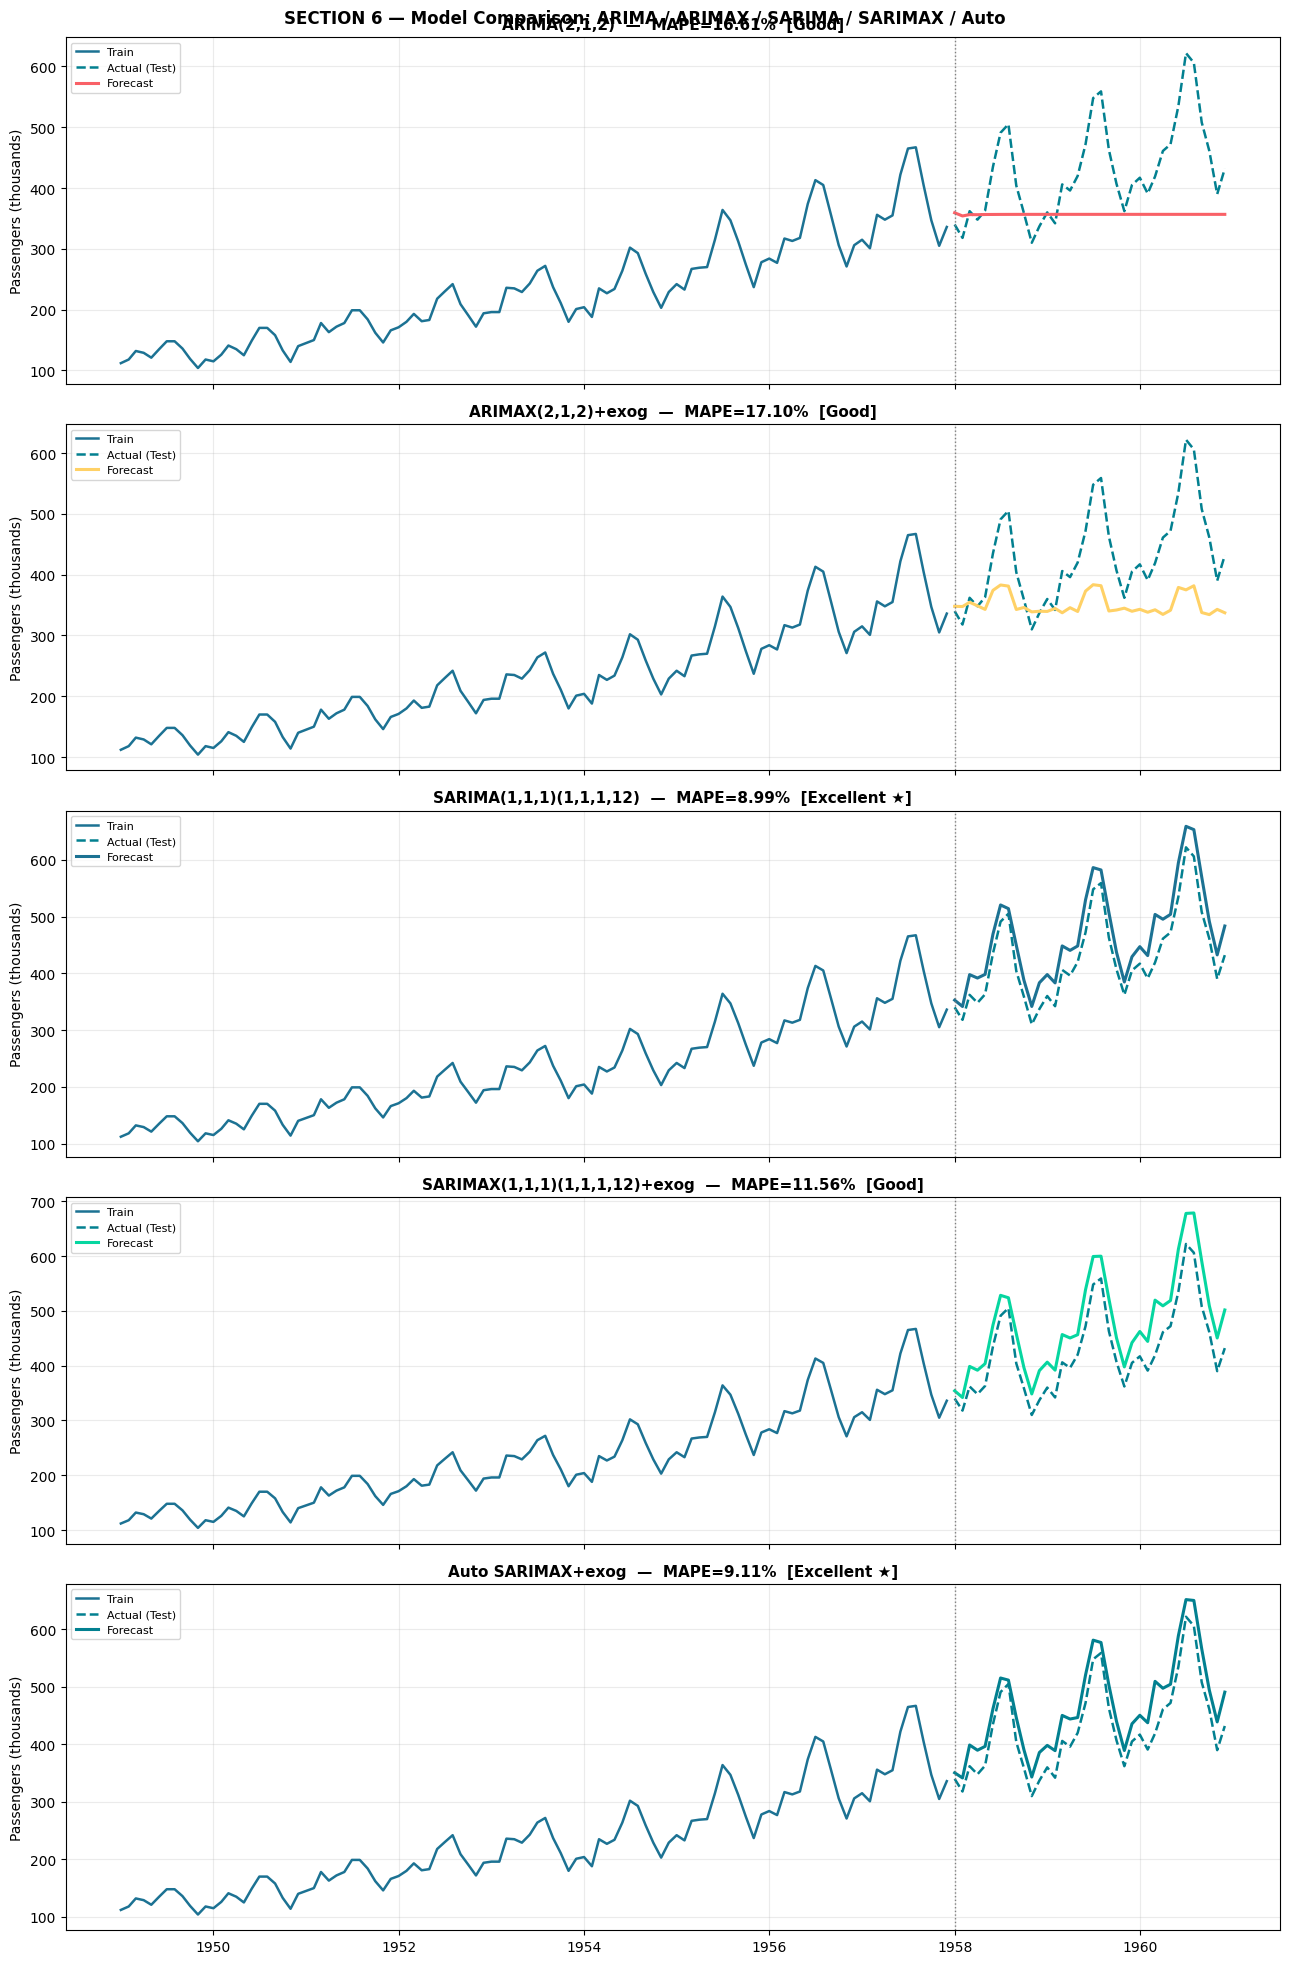

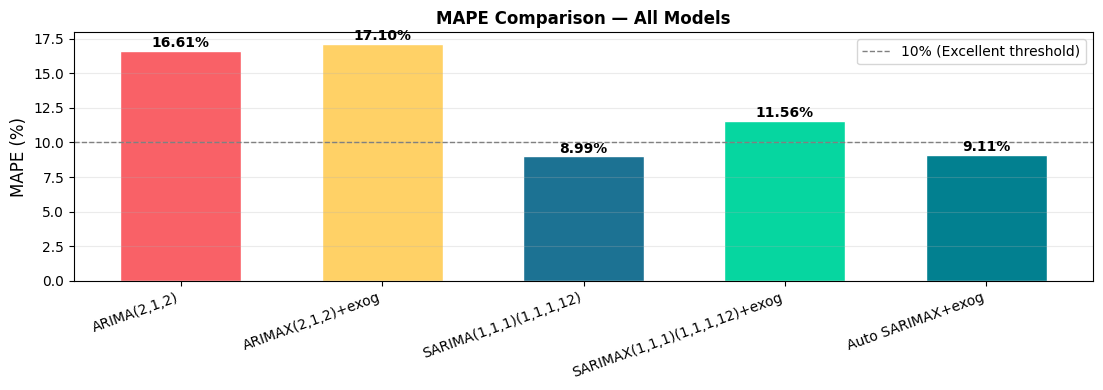

In [11]:
# =============================================================================
# SECTION 6 : Model Comparison
# =============================================================================
print("\n" + "=" * 65)
print("  SECTION 6 : Model Comparison")
print("=" * 65)

# Recompute ARIMA & SARIMA (no exog) for fair comparison
arima_fc_log = SARIMAX(train_log, order=(2,1,2),
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)\
                   .get_forecast(steps=len(test_log)).predicted_mean
arima_fc = np.exp(arima_fc_log)
mae_arima, rmse_arima, mape_arima = compute_metrics(test_raw, arima_fc)

sarima_fc_log = SARIMAX(train_log, order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)\
                    .get_forecast(steps=len(test_log)).predicted_mean
sarima_fc = np.exp(sarima_fc_log)
mae_sarima, rmse_sarima, mape_sarima = compute_metrics(test_raw, sarima_fc)

all_models = [
    ("ARIMA(2,1,2)",                        mae_arima,   rmse_arima,   mape_arima,   arima_fc,        "#F96167"),
    ("ARIMAX(2,1,2)+exog",                  mae_arimax,  rmse_arimax,  mape_arimax,  arimax_fc.values,"#FFD166"),
    ("SARIMA(1,1,1)(1,1,1,12)",             mae_sarima,  rmse_sarima,  mape_sarima,  sarima_fc,       "#1C7293"),
    ("SARIMAX(1,1,1)(1,1,1,12)+exog",       mae_sarimax, rmse_sarimax, mape_sarimax, sarimax_fc.values,"#06D6A0"),
    ("Auto SARIMAX+exog",                   mae_auto,    rmse_auto,    mape_auto,    auto_fc,         "#028090"),
]

print(f"\n  {'Model':<40}  {'MAE':>7}  {'RMSE':>7}  {'MAPE':>7}  Grade")
print("  " + "─"*70)
for name, mae, rmse, mape, _, __ in all_models:
    grade = "Excellent" if mape<10 else "Good" if mape<20 else "Acceptable"
    print(f"  {name:<40}  {mae:7.2f}  {rmse:7.2f}  {mape:6.2f}%  {grade}")

print("""
  Key Insights:
    ARIMA  → baseline, trend only, no seasonality, no exog
    ARIMAX → adding X helps, but no seasonality → limited
    SARIMA → seasonality helps significantly
    SARIMAX→ seasonality + exog = best overall model
    Auto   → automated, competitive, no manual tuning needed
""")

# ── Comparison plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(all_models), 1, figsize=(13, 20), sharex=True)

for ax, (name, mae, rmse, mape, fc, color) in zip(axes, all_models):
    grade = "Excellent ★" if mape<10 else "Good" if mape<20 else "Acceptable"
    plot_forecast(ax, train_raw, test_raw, fc,
                  title=f"{name}  —  MAPE={mape:.2f}%  [{grade}]",
                  fc_color=color)

plt.suptitle("SECTION 6 — Model Comparison: ARIMA / ARIMAX / SARIMA / SARIMAX / Auto",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── MAPE bar chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
names_c  = [m[0] for m in all_models]
mapes_c  = [m[3] for m in all_models]
colors_c = [m[5] for m in all_models]

bars = ax.bar(range(len(names_c)), mapes_c, color=colors_c,
              edgecolor="white", width=0.6)
ax.set_xticks(range(len(names_c)))
ax.set_xticklabels(names_c, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("MAPE (%)", fontsize=12)
ax.set_title("MAPE Comparison — All Models", fontsize=12, fontweight="bold")
ax.axhline(10, color="gray", ls="--", lw=1.0, label="10% (Excellent threshold)")
ax.legend(); ax.grid(True, alpha=0.25, axis="y")
for bar, val in zip(bars, mapes_c):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 7 : Future Forecast with Exogenous (1961)

  Important:  When forecasting with SARIMAX,
              you MUST provide X values for the future period.

  Approach:
    - oil_index  : extrapolate the trend (linear projection)
    - recession  : set to 0 (no recession assumed for 1961)
    - marketing  : follow the same summer campaign pattern


  Future exogenous variables (1961):
            oil_index  recession  marketing
1961-01-01  30.418813        0.0        0.0
1961-02-01  30.747094        0.0        0.0
1961-03-01  29.805019        0.0        0.0
1961-04-01  29.830577        0.0        0.0
1961-05-01  30.819087        0.0        0.0
1961-06-01  30.773920        0.0        1.0
1961-07-01  30.817986        0.0        1.0
1961-08-01  30.933274        0.0        1.0
1961-09-01  30.487349        0.0        0.0
1961-10-01  31.010800        0.0        0.0
1961-11-01  31.108520        0.0        0.0
1961-12-01  30.672119        0.0        0.0


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  1961 SARIMAX Forecast:
    1961-01     453   CI: [422, 486]
    1961-02     428   CI: [395, 463]
    1961-03     484   CI: [443, 528]
    1961-04     494   CI: [450, 543]
    1961-05     515   CI: [466, 570]
    1961-06     586   CI: [526, 652]
    1961-07     678   CI: [605, 758]
    1961-08     679   CI: [604, 765]
    1961-09     563   CI: [498, 637]
    1961-10     502   CI: [441, 571]
    1961-11     437   CI: [382, 499]
    1961-12     484   CI: [421, 555]


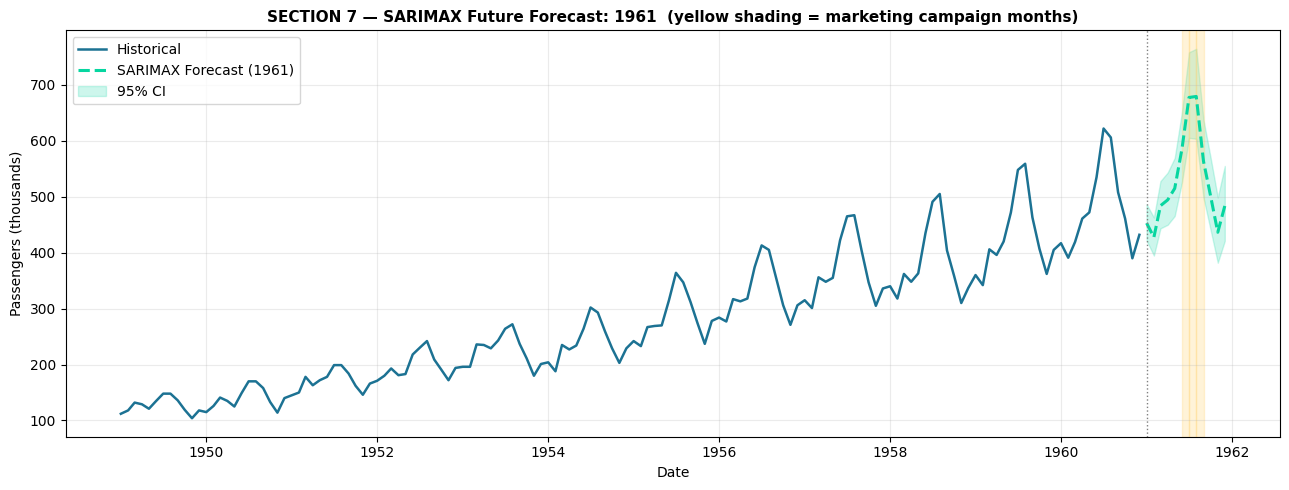


  ARIMAX / SARIMAX Analysis Complete
  arimax_00_data_overview.png          — Y + 3 exogenous variables
  arimax_01_residual_motivation.png    — why exog needed
  arimax_02_ARIMAX_forecast.png        — ARIMAX forecast + residuals
  arimax_03_SARIMAX_forecast.png       — SARIMAX forecast + residuals
  arimax_04_ablation.png               — variable importance study
  arimax_05_auto_sarimax.png           — auto_arima with exog
  arimax_06_model_comparison.png       — all 5 models side-by-side
  arimax_06_mape_bar.png               — MAPE bar chart
  arimax_07_future_forecast.png        — 1961 forecast with future X

  Model Hierarchy Summary:
    ARIMA   → no exog, no seasonal
    ARIMAX  → + external variables  (no seasonal)
    SARIMA  → + seasonal component  (no exog)
    SARIMAX → + seasonal + external  ← most complete
    Auto    → automated order selection for SARIMAX



In [12]:
# =============================================================================
# SECTION 7 : Future Forecast with Exogenous (1961)
# =============================================================================
print("\n" + "=" * 65)
print("  SECTION 7 : Future Forecast with Exogenous (1961)")
print("=" * 65)
print("""
  Important:  When forecasting with SARIMAX,
              you MUST provide X values for the future period.
  
  Approach:
    - oil_index  : extrapolate the trend (linear projection)
    - recession  : set to 0 (no recession assumed for 1961)
    - marketing  : follow the same summer campaign pattern
""")

fut_idx   = pd.date_range(start="1961-01", periods=12, freq="MS")

# Project future X
oil_last  = exog["oil_index"].iloc[-1]
oil_slope = (exog["oil_index"].iloc[-1] - exog["oil_index"].iloc[0]) / (n - 1)
oil_future = oil_last + oil_slope * np.arange(1, 13) + np.random.normal(0, 0.5, 12)

rec_future = np.zeros(12)      # no recession assumed

mkt_future = np.zeros(12)
mkt_future[5] = 1; mkt_future[6] = 1; mkt_future[7] = 1  # Jun/Jul/Aug

exog_future = pd.DataFrame({
    "oil_index": oil_future,
    "recession": rec_future,
    "marketing": mkt_future,
}, index=fut_idx)

print("\n  Future exogenous variables (1961):")
print(exog_future.to_string())

# Refit SARIMAX on full dataset
full_sarimax = SARIMAX(
    log_data,
    exog           = exog,
    order          = (1, 1, 1),
    seasonal_order = (1, 1, 1, 12),
    enforce_stationarity = False,
    enforce_invertibility= False
).fit(disp=False)

fut_fc_obj = full_sarimax.get_forecast(steps=12, exog=exog_future)
fut_fc     = np.exp(fut_fc_obj.predicted_mean)
fut_ci     = np.exp(fut_fc_obj.conf_int())
fut_fc.index     = fut_idx
fut_ci.index     = fut_idx

print("\n  1961 SARIMAX Forecast:")
for d, v, lo, hi in zip(fut_idx, fut_fc, fut_ci.iloc[:,0], fut_ci.iloc[:,1]):
    print(f"    {d.strftime('%Y-%m')}  {v:6.0f}   CI: [{lo:.0f}, {hi:.0f}]")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(data.index, data.values, color="#1C7293", lw=1.8, label="Historical")
ax.plot(fut_idx, fut_fc.values, color="#06D6A0", lw=2.2, ls="--",
        label="SARIMAX Forecast (1961)")
ax.fill_between(fut_idx, fut_ci.iloc[:,0], fut_ci.iloc[:,1],
                color="#06D6A0", alpha=0.2, label="95% CI")
# shade marketing months
for d in fut_idx:
    if exog_future.loc[d, "marketing"] == 1:
        ax.axvspan(d, d + pd.DateOffset(months=1),
                   color="#FFD166", alpha=0.25)
ax.axvline(fut_idx[0], color="gray", ls=":", lw=1.0)
ax.set_title("SECTION 7 — SARIMAX Future Forecast: 1961  "
             "(yellow shading = marketing campaign months)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Passengers (thousands)")
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# =============================================================================
print("\n" + "=" * 65)
print("  ARIMAX / SARIMAX Analysis Complete")
print("=" * 65)
files = [
    "arimax_00_data_overview.png          — Y + 3 exogenous variables",
    "arimax_01_residual_motivation.png    — why exog needed",
    "arimax_02_ARIMAX_forecast.png        — ARIMAX forecast + residuals",
    "arimax_03_SARIMAX_forecast.png       — SARIMAX forecast + residuals",
    "arimax_04_ablation.png               — variable importance study",
    "arimax_05_auto_sarimax.png           — auto_arima with exog",
    "arimax_06_model_comparison.png       — all 5 models side-by-side",
    "arimax_06_mape_bar.png               — MAPE bar chart",
    "arimax_07_future_forecast.png        — 1961 forecast with future X",
]
for f in files:
    print(f"  {f}")
print("=" * 65)

print("""
  Model Hierarchy Summary:
    ARIMA   → no exog, no seasonal
    ARIMAX  → + external variables  (no seasonal)
    SARIMA  → + seasonal component  (no exog)
    SARIMAX → + seasonal + external  ← most complete
    Auto    → automated order selection for SARIMAX
""")